<a href="https://colab.research.google.com/github/andreimotruc13-lab/AD-Fusion-Career-Architect/blob/main/Job_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#df = pd.read_csv('job_descriptions.csv')

In [ ]:
#df_small = df.sample(n=100000, random_state=42)


In [ ]:
#df_small.to_csv('descriptions_min.csv', index=False)

In [ ]:
df_small = pd.read_csv('descriptions_min.csv')

In [ ]:
display(df_small)

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,543021984846292,0 to 12 Years,PhD,$55K-$99K,Stockholm,Sweden,60.1282,18.6435,Intern,61788,...,432-386-1896x4330,Software Engineer,Backend Developer,ZipRecruiter,A Backend Developer is tasked with building an...,"{'Transportation Benefits, Professional Develo...",Proficiency in one or more backend programming...,Develop server-side logic and databases using ...,AT&T,"{""Sector"":""Telecommunications"",""Industry"":""Tel..."
1,438124851778828,4 to 14 Years,M.Com,$55K-$118K,Nuuk,Greenland,71.7069,-42.6043,Full-Time,62122,...,001-301-329-6278x40627,Procurement Manager,Supplier Diversity Manager,Glassdoor,Promote diversity and inclusion in the supply ...,"{'Health Insurance, Retirement Plans, Flexible...",Supplier diversity programs Diversity and incl...,Promote supplier diversity initiatives and inc...,Owens & Minor,"{""Sector"":""Healthcare Services"",""Industry"":""Wh..."
2,1372559742314878,3 to 13 Years,BCA,$60K-$102K,Tehran,"Iran, Islamic Rep.",32.4279,53.6880,Part-Time,79605,...,(380)520-8257,Software Engineer,Frontend Developer,SimplyHired,A Frontend Developer is responsible for design...,"{'Health Insurance, Retirement Plans, Flexible...","Proficiency in HTML, CSS, and JavaScript Exper...",Design and implement user interfaces for web a...,Northern Star Resources,"{""Sector"":""Mining and Metals/Gold"",""Industry"":..."
3,2068120866778955,2 to 12 Years,B.Tech,$64K-$82K,Managua,Nicaragua,12.8654,-85.2072,Full-Time,70697,...,+1-710-924-4346x248,Supply Chain Manager,Demand Planner,Indeed,A Demand Planner analyzes historical sales dat...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Demand forecasting Inventory management Data a...,Analyze demand patterns and market trends to f...,Sun TV Network,"{""Sector"":""Media & Entertainment"",""Industry"":""..."
4,2628689768568735,5 to 11 Years,PhD,$65K-$97K,New Delhi,India,20.5937,78.9629,Part-Time,96919,...,612.871.8034x965,Financial Analyst,Budget Analyst,Jobs2Careers,Budget Analysts manage and analyze financial d...,"{'Health Insurance, Retirement Plans, Flexible...",Budget planning Financial forecasting Excel pr...,"Develop and manage budgets, track financial pe...",The Boeing Company,"{""Sector"":""Aerospace/Defense"",""Industry"":""Aero..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,483313716104282,4 to 8 Years,MCA,$60K-$90K,Monrovia,Liberia,6.4281,-9.4295,Part-Time,129566,...,+1-820-667-9235x920,Investment Banker,Investment Portfolio Manager,Snagajob,An Investment Portfolio Manager manages invest...,"{'Childcare Assistance, Paid Time Off (PTO), R...",Investment analysis Portfolio management Risk ...,Manage investment portfolios on behalf of clie...,V-Guard Industries,"{""Sector"":""Electrical Equipment"",""Industry"":""E..."
99996,590623009240861,0 to 10 Years,M.Tech,$59K-$114K,Thimphu,Bhutan,27.5142,90.4336,Temporary,22703,...,562.230.3207,Investment Analyst,Portfolio Manager,Dice,A Portfolio Manager oversees investment portfo...,"{'Transportation Benefits, Professional Develo...",Investment management Financial analysis Risk ...,"Manage investment portfolios, making investmen...",Cardinal Health,"{""Sector"":""Healthcare"",""Industry"":""Wholesalers..."
99997,1373852178298290,3 to 8 Years,PhD,$56K-$102K,Nouakchott,Mauritania,21.0079,-10.9408,Temporary,93418,...,(457)525-6794,UX Researcher,Usability Analyst,SimplyHired,Evaluate and improve the usability of websites...,"{'Health Insurance, Retirement Plans, Flexible...",Usability evaluation User interface assessment...,Focus on usability testing of digital products...,WEC Energy Group,"{""Sector"":""Utilities"",""Industry"":""Utilities: G..."
99998,2966851666436664,0 to 13 Years,BCA,$57K-$104K,Antananarivo,Madagascar,-18.8792,46.8451,Full-Time,13984,...,+1-35

# Initial vizualization of data

In [ ]:
df_small.columns

Index(['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location',
       'Country', 'latitude', 'longitude', 'Work Type', 'Company Size',
       'Job Posting Date', 'Preference', 'Contact Person', 'Contact',
       'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits',
       'skills', 'Responsibilities', 'Company', 'Company Profile'],
      dtype='object')

In [ ]:
df_train = df_small.drop([
    'location', 'latitude',
    'longitude', 'Company Size',
    'Job Posting Date', 'Contact Person', 'Contact',
    'Job Title', 'Job Portal', 'Company',
    'Company Profile', 'Job Description', 'Responsibilities',
    'Job Id'
    ], axis = 1)

In [ ]:
df_train.columns

Index(['Experience', 'Qualifications', 'Salary Range', 'Country', 'Work Type',
       'Preference', 'Role', 'Benefits', 'skills'],
      dtype='object')

In [ ]:
df_train['Qualifications'].unique()

array(['PhD', 'M.Com', 'BCA', 'B.Tech', 'M.Tech', 'MBA', 'BA', 'MCA',
       'BBA', 'B.Com'], dtype=object)

# Preprocessing


In [ ]:
#Putting the experience column in a min and max column
if 'Experience' in df_train.columns:
  extracted_years = df_train['Experience'].str.extract(r'(\d+)\s*to\s*(\d+)')
  df_train['Min_experience'] = extracted_years[0].astype(float)
  df_train['Max_experience'] = extracted_years[1].astype(float)
  df_train.drop(columns = ['Experience'], inplace=True)

In [ ]:
#Mapping for the qualification columns in dependency of impact
df_train['Qualifications'] = df_train['Qualifications'].str.strip()
job_market_mapping = {
    'BA': 1,
    'B.Com': 1,
    'BBA': 1,

    'BCA': 2,
    'B.Tech': 2,

    'M.Com': 3,
    'MBA': 3,

    'MCA': 4,
    'M.Tech': 4,

    'PhD': 5
}
df_train['Qualifications'] = df_train['Qualifications'].map(job_market_mapping)

In [ ]:
#Initial strategy we had for the salary column using midpoint(gets overrun by next block)
if 'Salary Range' in df_train.columns:
  df_train['Salary Range'] = df_train['Salary Range'].str.strip()
  extracted_salaries = df_train['Salary Range'].str.extract(r'(\d+).*?(\d+)')
  s1 = pd.to_numeric(extracted_salaries[0])
  s2 = pd.to_numeric(extracted_salaries[1])
  df_train['Salary'] = (s1 + s2) / 2
  df_train.drop(columns=['Salary Range'], inplace=True)

In [ ]:
#Mapping the salaries and cities
moldova_cities = ['Chisinau', 'Balti', 'Tiraspol', 'Cahul', 'Ungheni', 'Stauceni', 'Orhei', 'Edinet', 'Soroca', 'Comrat']

salary_map = {
    1: 14.0,
    2: 17.5,
    3: 21.0,
    4: 24.5,
    5: 28.0
}

shared_cities = np.random.choice(moldova_cities, size=len(df_train))

def get_synchronized_data(df):
    numeric_salaries = []
    range_salaries = []

    #Adding noise for a better dataset
    for idx, row in df.iterrows():
        q_level = int(row['Qualifications'])
        base = salary_map.get(q_level, 18.0)

        noise = round(np.random.uniform(-1.5, 1.5), 1)
        point_salary = base + noise

        low_bound = int(point_salary - 2)
        high_bound = int(point_salary + 2)
        range_str = f"${low_bound}K-${high_bound}K"

        numeric_salaries.append(point_salary)
        range_salaries.append(range_str)

    return numeric_salaries, range_salaries

numeric_list, range_list = get_synchronized_data(df_train)


df_train['City'] = shared_cities
df_train['Salary'] = numeric_list

if 'Country' in df_train.columns: df_train.drop(columns=['Country'], inplace=True)

df_small['City'] = shared_cities
df_small['Salary Range'] = range_list

if 'Country' in df_small.columns: df_small.drop(columns=['Country'], inplace=True)


In [ ]:
if 'location' in df_small:
  df_small.drop(columns = ['location', 'latitude', 'longitude', 'Company Profile'], inplace=True)

In [ ]:
df_train['Work Type'].unique()

array(['Intern', 'Full-Time', 'Part-Time', 'Contract', 'Temporary'],
      dtype=object)

In [ ]:
#Mapping for work types
df_train['Work Type'] = df_train['Work Type'].str.strip()
work_mapping = {
    'Intern': 1,
    'Part-Time': 2,
    'Temporary': 3,
    'Contract': 4,
    'Full-Time': 5
}
df_train['Work Type'] = df_train['Work Type'].map(work_mapping)


In [ ]:
#Encoding the gender preferences
dummies_gender = pd.get_dummies(df_train['Preference'], drop_first=True)
df_train = pd.concat([df_train, dummies_gender], axis = 1)

In [ ]:
df_train.drop(columns=['Preference'], inplace=True)

In [ ]:
df_train[['Female', 'Male']] = df_train[['Female', 'Male']].astype(int)

In [ ]:
#Encoding the cities
dummies_city = pd.get_dummies(df_train['City'], drop_first=True, dtype = int)
df_train = pd.concat([df_train, dummies_city], axis = 1)
df_train.drop('City', axis = 1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

#Encoding all the roles for possible future use
le = LabelEncoder()
df_train['Role_encoded'] = le.fit_transform(df_train['Role'])
df_train.drop('Role', axis = 1, inplace=True)

In [ ]:
#Encoding all the benefits
df_train['Benefits'] = df_train['Benefits'].str.replace(r"[{}[\]']", '', regex=True)
dummies_benefits = df_train['Benefits'].str.get_dummies(sep = ', ')
df_train = pd.concat([df_train, dummies_benefits], axis = 1)

In [ ]:
df_train.drop(columns=['Benefits'], inplace=True)

In [ ]:
df_train.head()

,Qualifications,Work Type,skills,Min_experience,Max_experience,Salary,Female,Male,Cahul,Chisinau,...,Parental Leave,Professional Development,Profit-Sharing,Relocation Assistance,Retirement Plans,Social and Recreational Activities,Stock Options or Equity Grants,Transportation Benefits,Tuition Reimbursement,Wellness Programs
0,5,1,Proficiency in one or more backend programming...,0.0,12.0,27.6,0,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,3,5,Supplier diversity programs Diversity and incl...,4.0,14.0,20.6,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2,2,"Proficiency in HTML, CSS, and JavaScript Exper...",3.0,13.0,18.0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,2,5,Demand forecasting Inventory management Data a...,2.0,12.0,18.8,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,2,Budget planning Financial forecasting Excel pr...,5.0,11.0,26.8,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
import re

#Preprocessing skills column
def clean_skills_reset(text):
    text = re.sub(r'\s*\(.*?\)\s*', ' ', text)

    text = text.replace(',', '').replace('.', '')

    text = re.sub(r'\band\b', '', text)

    text = re.sub(r'\s+([A-Z][a-z])', r', \1', text)

    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'^, ', '', text)

    return text

if 'skills' in df_train:
  df_train['skills_ready'] = df_train['skills'].apply(clean_skills_reset)
  df_train.drop('skills', axis = 1, inplace=True)

In [ ]:
#This block maps and encodes the skills column using a a large amount of skills in
#multiple industries
granular_mapping = {
    # IT & Software
    'Tech_Backend': ['backend', 'java', 'python', 'node', 'api', 'server', 'sql', 'nosql', 'database', 'restful', 'mongodb'],
    'Tech_Frontend': ['frontend', 'html', 'css', 'javascript', 'react', 'angular', 'vue', 'ui design', 'responsive', 'ux/ui'],
    'Tech_DevOps_Cloud': ['cloud', 'aws', 'azure', 'docker', 'kubernetes', 'devops', 'security', 'cyber', 'network', 'firewall', 'intrusion'],
    'Tech_Data_AI': ['data analysis', 'machine learning', 'deep learning', 'statistics', 'tableau', 'power bi', 'visualization', 'bi ', 'analytics'],

    # Business & Management
    'Mgmt_Project_Agile': ['project management', 'agile', 'scrum', 'kanban', 'roadmap', 'stakeholder', 'waterfall', 'jira'],
    'Mgmt_Strategic_Leadership': ['strategic planning', 'business strategy', 'team leadership', 'sales leadership', 'executive', 'leadership management'],

    # Finance & Legal
    'Fin_Accounting_Audit': ['accounting', 'gaap', 'audit', 'quickbooks', 'financial reporting', 'tax planning', 'bookkeeping', 'budgeting'],
    'Fin_Analysis_Investment': ['financial analysis', 'financial modeling', 'investment', 'portfolio', 'risk assessment', 'asset allocation'],
    'Legal_Services': ['law', 'legal', 'litigation', 'contract', 'intellectual property', 'court', 'compliance', 'trademark', 'copyright'],

    # Marketing & Creative
    'Mkt_Digital_SEO': ['digital marketing', 'seo', 'sem', 'content marketing', 'email marketing', 'google analytics', 'social media', 'advertising', 'ppc'],
    'Creative_Design_Art': ['design', 'graphic', 'adobe', 'creative', 'brand', 'artistic', 'typography', 'prototype', 'sketch', 'figma'],

    # Health & Science
    'Health_Medical': ['nursing', 'patient', 'medical', 'clinical', 'geriatric', 'pediatric', 'diagnosis', 'therapy', 'dental', 'orthopedic'],
    'Science_Engineering': ['engineering', 'chemical', 'mechanical', 'aerospace', 'laboratory', 'cad ', 'autocad', 'circuit', 'electronics'],

    # Servicii & Niche
    'Service_Events': ['wedding', 'event', 'catering', 'vendor', 'hospitality', 'ceremony', 'logistics'],
    'Service_Specialized': ['animal', 'horse', 'equine', 'reptile', 'amphibian', 'vet ', 'agriculture', 'urban planning', 'landscape']
}

soft_keywords = ['communication', 'problem-solving', 'empathy', 'critical thinking', 'adaptability', 'interpersonal', 'teamwork', 'leadership skills']

def apply_mapping(text, keywords):
    text = str(text).lower()
    return 1 if any(k in text for k in keywords) else 0

#Count number of soft skills (list of them is above)
def calculate_soft_score(text, keywords):
    text = str(text).lower()
    return sum(1 for k in keywords if k in text)

for category, keywords in granular_mapping.items():
    df_train[category] = df_train['skills_ready'].apply(lambda x: apply_mapping(x, keywords))

df_train['Soft_Skills_Score'] = df_train['skills_ready'].apply(lambda x: calculate_soft_score(x, soft_keywords))


In [ ]:
df_train.drop('skills_ready', axis=1, inplace=True)

In [ ]:
df_train.head()

,Qualifications,Work Type,Min_experience,Max_experience,Salary,Female,Male,Cahul,Chisinau,Comrat,...,Fin_Accounting_Audit,Fin_Analysis_Investment,Legal_Services,Mkt_Digital_SEO,Creative_Design_Art,Health_Medical,Science_Engineering,Service_Events,Service_Specialized,Soft_Skills_Score
0,5,1,0.0,12.0,27.6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,5,4.0,14.0,20.6,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,1
2,2,2,3.0,13.0,18.0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,2,5,2.0,12.0,18.8,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,2,5.0,11.0,26.8,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#df_train.to_csv('processed.csv', index = False)

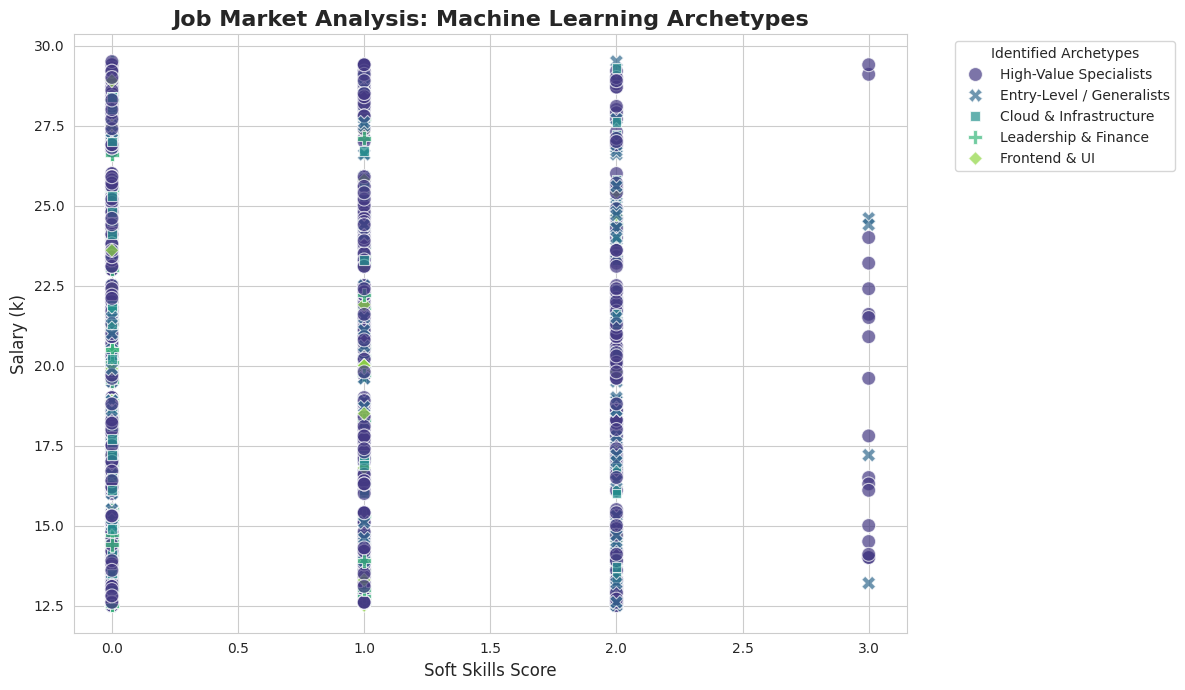

--- Cluster Summary for Presentation ---
                           Salary  Soft_Skills_Score  Min_experience
Archetype                                                           
Cloud & Infrastructure      19.55               0.30            2.49
Entry-Level / Generalists   19.59               0.58            2.48
Frontend & UI               19.52               0.54            2.50
High-Value Specialists      19.58               0.48            2.49
Leadership & Finance        19.50               0.31            2.49


In [ ]:
#The block we used for viewing our dataset with our soft skills
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# We are including tech domains, management, and finance columns + core metrics in our logic sets
tech_cols = [col for col in df_train.columns if any(p in col for p in ['Tech_', 'Mgmt_', 'Fin_'])]
features = tech_cols + ['Salary', 'Min_experience', 'Soft_Skills_Score']

# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_train[features])

# We use 5 clusters to represent our market archetypes
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_train['Cluster'] = kmeans.fit_predict(X_scaled)

# Mapping Cluster IDs to something readable
cluster_map = {
    0: "High-Value Specialists",
    1: "Cloud & Infrastructure",
    2: "Leadership & Finance",
    3: "Entry-Level / Generalists",
    4: "Frontend & UI"
}
df_train['Archetype'] = df_train['Cluster'].map(cluster_map)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Using a sample for the scatter plot to maintain clarity while showing density
plot_df = df_train.sample(2000, random_state=42)

scatter = sns.scatterplot(
    data=plot_df,
    x='Soft_Skills_Score',
    y='Salary',
    hue='Archetype',
    style='Archetype',
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Job Market Analysis: Machine Learning Archetypes', fontsize=16, fontweight='bold')
plt.xlabel('Soft Skills Score', fontsize=12)
plt.ylabel('Salary (k)', fontsize=12)
plt.legend(title='Identified Archetypes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('cluster_archetypes.png', dpi=300)
plt.show()

# A small summary table
summary = df_train.groupby('Archetype')[['Salary', 'Soft_Skills_Score', 'Min_experience']].mean()
print("Cluster Summary for Presentation:")
print(summary.round(2))

# Antrenare

In [ ]:
#Block of code we used for the initial training and testing of our recommender model
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['Min_experience', 'Max_experience', 'Salary', 'Soft_Skills_Score', 'Qualifications', 'Work Type']

tech_prefixes = ['Tech_', 'Mgmt_', 'Fin_', 'Legal_', 'Mkt_', 'Creative_', 'Health_', 'Science_', 'Service_']
tech_cols = [col for col in df_train.columns if any(p in col for p in tech_prefixes)]

target_col = 'Role_encoded'
exclude = num_cols + tech_cols + [target_col]
benefit_cols = [col for col in df_train.columns if col not in exclude]

df_weighted = df_train.copy()

#Applying weights to certain columns
for col in tech_cols:
    df_weighted[col] = df_weighted[col] * 20.0

for col in benefit_cols:
    df_weighted[col] = df_weighted[col] * 0.5

binary_cols_weighted = tech_cols + benefit_cols

#Avoiding sparse matrices(initially led to extremely low accuracy)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('binary_essence', TruncatedSVD(n_components=15, random_state=42), binary_cols_weighted)
])

X_processed = preprocessor.fit_transform(df_weighted)

recommender = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
recommender.fit(X_processed)


def get_recommendations(user_index, df_details, num_matches=5):

    distances, indices = recommender.kneighbors(X_processed[user_index].reshape(1, -1))
    recommended_indices = indices[0][1:num_matches+1]

    print(f"MATCHES FOR: {df_details.iloc[user_index]['Role']}")
    results = df_details.iloc[recommended_indices]

    for i, (idx, row) in enumerate(results.iterrows()):

        raw_dist = distances[0][i+1]
        #We applied a strictness formula because the initial tests
        #were made with values from this dataset and the accuracy
        #was impossibly high (due to the cosinus metric method)
        strictness = 35
        realistic_score = np.exp(-strictness * raw_dist) * 100

        if realistic_score > 99.9: realistic_score = 99.9

        print(f"\n[{i+1}] {row['Job Title']}")
        print(f"Role: {row['Role']}")
        print(f"Company: {row['Company']}")
        print(f"Match Strength: {realistic_score:.1f}%")

    return results

# result_df = get_recommendations(0, df_small)

In [ ]:
result_df = get_recommendations(99995, df_small)

--- MATCHES FOR: Investment Portfolio Manager ---

[1] Financial Advisor
Role: Wealth Management Advisor
Company: News Corp.
Match Strength: 99.7%

[2] Financial Analyst
Role: Financial Planner
Company: Blackstone
Match Strength: 99.2%

[3] Financial Analyst
Role: Financial Planner
Company: Targa Resources
Match Strength: 99.2%

[4] Investment Analyst
Role: Portfolio Manager
Company: Molson Coors Beverage
Match Strength: 99.1%

[5] Financial Analyst
Role: Financial Planner
Company: Universal Health Services
Match Strength: 99.0%


# Other tests

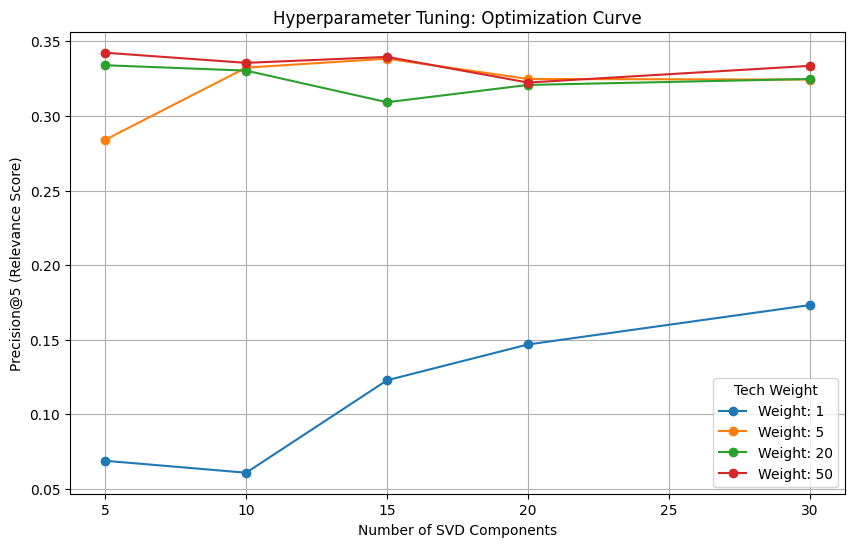

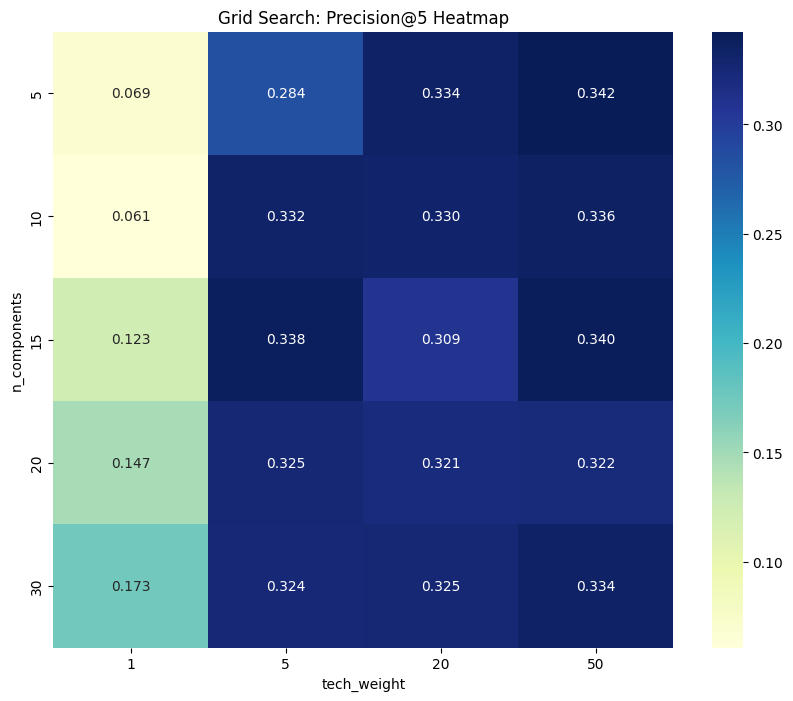

In [ ]:
#Evaluating the model and seeing what parameters we should choose
#(By parameteres we mainly mean the number of SVD components and the optimal
#weight to apply to the tech columns)
def evaluate_model(n_comp, tech_weight):
    df_temp = df_train.copy()
    for col in tech_cols:
        df_temp[col] = df_temp[col] * tech_weight
    for col in benefit_cols:
        df_temp[col] = df_temp[col] * 0.5

    binary_cols = tech_cols + benefit_cols
    preprocessor_temp = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('binary_essence', TruncatedSVD(n_components=n_comp, random_state=42), binary_cols)
    ])

    X_temp = preprocessor_temp.fit_transform(df_temp)
    nn_temp = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
    nn_temp.fit(X_temp)

    sample_size = 500
    sample_idx = np.random.choice(len(df_train), sample_size, replace=False)
    _, neighbors = nn_temp.kneighbors(X_temp[sample_idx])

    hits = 0
    for i, idx in enumerate(sample_idx):
        target_role = df_train.iloc[idx]['Role_encoded']

        neighbor_roles = df_train.iloc[neighbors[i][1:]]['Role_encoded'].values
        hits += np.sum(neighbor_roles == target_role)

    return hits / (sample_size * 5)

components_to_test = [5, 10, 15, 20, 30]
weights_to_test = [1, 5, 20, 50]

results = []
for c in components_to_test:
    for w in weights_to_test:
        score = evaluate_model(c, w)
        results.append({'n_components': c, 'tech_weight': w, 'precision': score})

res_df = pd.DataFrame(results)
pivot_df = res_df.pivot(index='n_components', columns='tech_weight', values='precision')

#Line plot with multiple tests
plt.figure(figsize=(10, 6))
for w in weights_to_test:
    subset = res_df[res_df['tech_weight'] == w]
    plt.plot(subset['n_components'], subset['precision'], marker='o', label=f'Weight: {w}')

plt.title('Hyperparameter Tuning: Optimization Curve')
plt.xlabel('Number of SVD Components')
plt.ylabel('Precision@5 (Relevance Score)')
plt.legend(title="Tech Weight")
plt.grid(True)
plt.show()

#Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('Grid Search: Precision@5 Heatmap')
plt.show()

In [ ]:
import random

#Testing code for the dataset viewer on second tab
df_small['Contact'] = None

prefix = ['60', '68', '69', '78', '79']
rand_numbers = [f"+373{random.choice(prefix)}{random.randint(100000, 999999)}" for _ in range(20)]

df_small['Contact'] = [random.choice(rand_numbers) for _ in range(len(df_small))]


In [ ]:
print(df_small[['Contact']].head(15))

         Contact
0   +37368616868
1   +37369855583
2   +37369275646
3   +37368906145
4   +37368723575
5   +37369920359
6   +37360674635
7   +37368494858
8   +37368723575
9   +37368494858
10  +37379709855
11  +37368494858
12  +37369719961
13  +37369330299
14  +37369920359


In [ ]:
df_main = df_small.drop([
    'Job Id', 'Company Size', 'Preference',
    'Job Portal'
], axis = 1)

In [ ]:
display(df_main.head())

,Experience,Qualifications,Salary Range,Work Type,Job Posting Date,Contact Person,Contact,Job Title,Role,Job Description,Benefits,skills,Responsibilities,Company,City
0,0 to 12 Years,PhD,$25K-$29K,Intern,2023-03-02,Michael Garcia,+37368616868,Software Engineer,Backend Developer,A Backend Developer is tasked with building an...,"{'Transportation Benefits, Professional Develo...",Proficiency in one or more backend programming...,Develop server-side logic and databases using ...,AT&T,Edinet
1,4 to 14 Years,M.Com,$18K-$22K,Full-Time,2023-02-15,Ricky Williams,+37369855583,Procurement Manager,Supplier Diversity Manager,Promote diversity and inclusion in the supply ...,"{'Health Insurance, Retirement Plans, Flexible...",Supplier diversity programs Diversity and incl...,Promote supplier diversity initiatives and inc...,Owens & Minor,Edinet
2,3 to 13 Years,BCA,$16K-$20K,Part-Time,2021-12-20,Joseph Browning,+37369275646,Software Engineer,Frontend Developer,A Frontend Developer is responsible for design...,"{'Health Insurance, Retirement Plans, Flexible...","Proficiency in HTML, CSS, and JavaScript Exper...",Design and implement user interfaces for web a...,Northern Star Resources,Balti
3,2 to 12 Years,B.Tech,$16K-$20K,Full-Time,2023-03-26,Matthew Edwards,+37368906145,Supply Chain Manager,Demand Planner,A Demand Planner analyzes historical sales dat...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Demand forecasting Inventory management Data a...,Analyze demand patterns and market trends to f...,Sun TV Network,Balti
4,5 to 11 Years,PhD,$24K-$28K,Part-Time,2023-04-20,Angela Fisher,+37368723575,Financial Analyst,Budget Analyst,Budget Analysts manage and analyze financial d...,"{'Health Insurance, Retirement Plans, Flexible...",Budget planning Financial forecasting Excel pr...,"Develop and manage budgets, track financial pe...",The Boeing Company,Tiraspol


In [ ]:
df_main['Benefits'] = df_main['Benefits'].str.replace(r"[{}']", "", regex=True).str.strip()

In [ ]:
import joblib

joblib.dump(recommender, 'recommender.pkl')

['recommender.pkl']

In [ ]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [ ]:
#Hypothetical testing for other datasets
"""
def recommend_for_new_dataset(df_new_users, df_details, num_matches=5):

    required_cols = [col for col in df_train.columns if col != 'Role_encoded']
    print(required_cols)
    df_temp = df_new_users.copy()
    for col in required_cols:
        if col not in df_temp.columns:
            df_temp[col] = 0

    df_temp = df_temp[required_cols]

    for col in tech_cols:
        df_temp[col] = df_temp[col] * 20.0
    for col in benefit_cols:
        df_temp[col] = df_temp[col] * 0.5

    X_new_processed = preprocessor.transform(df_temp)

    for user_idx in range(len(X_new_processed)):
        distances, indices = recommender.kneighbors(X_new_processed[user_idx].reshape(1, -1))

        print(f"\nMATCHES FOR NEW USER {user_idx + 1}")

        recommended_indices = indices[0][:num_matches]
        results = df_details.iloc[recommended_indices]

        for i, (idx, row) in enumerate(results.iterrows()):
            raw_dist = distances[0][i]

            strictness = 35
            realistic_score = np.exp(-strictness * raw_dist) * 100
            if realistic_score > 99.9: realistic_score = 99.9

            print(f"[{i+1}] {row['Job Title']} | Match: {realistic_score:.1f}%")

    return results
"""
# results = recommend_for_new_dataset(df_new_people, df_small)